phase 1
----------------------
Load, Explore & Clean
-------------------------

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df=pd.read_csv("AmesHousing.csv")
print(df.head())
# [5 rows x 82 columns]

   Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0      1  526301100           20        RL         141.0     31770   Pave   
1      2  526350040           20        RH          80.0     11622   Pave   
2      3  526351010           20        RL          81.0     14267   Pave   
3      4  526353030           20        RL          93.0     11160   Pave   
4      5  527105010           60        RL          74.0     13830   Pave   

  Alley Lot Shape Land Contour  ... Pool Area Pool QC  Fence Misc Feature  \
0   NaN       IR1          Lvl  ...         0     NaN    NaN          NaN   
1   NaN       Reg          Lvl  ...         0     NaN  MnPrv          NaN   
2   NaN       IR1          Lvl  ...         0     NaN    NaN         Gar2   
3   NaN       Reg          Lvl  ...         0     NaN    NaN          NaN   
4   NaN       IR1          Lvl  ...         0     NaN  MnPrv          NaN   

  Misc Val Mo Sold Yr Sold Sale Type  Sale Condition  SalePrice  
0       

In [3]:
df.info()
# i used ai
# i used to_numeric For digital transformation,I used fillna to compensate for the missing values; if there are no NaN values, I can use regular int64, but if there are still missing values, I must use int64 (with a large I) because it does not support null values
df['Mas Vnr Area'] = pd.to_numeric(df['Mas Vnr Area'], errors='coerce').fillna(0).astype('int64')
df['BsmtFin SF 1'] = pd.to_numeric(df['BsmtFin SF 1'], errors='coerce').fillna(0).astype('int64')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [4]:
# i used ai to get the top colunm that have Nan value
missing_d=df.isnull().sum()
print(missing_d[missing_d>0])
# Pool QC have the most

Lot Frontage       490
Alley             2732
Mas Vnr Type      1775
Bsmt Qual           80
Bsmt Cond           80
Bsmt Exposure       83
BsmtFin Type 1      80
BsmtFin Type 2      81
BsmtFin SF 2         1
Bsmt Unf SF          1
Total Bsmt SF        1
Electrical           1
Bsmt Full Bath       2
Bsmt Half Bath       2
Fireplace Qu      1422
Garage Type        157
Garage Yr Blt      159
Garage Finish      159
Garage Cars          1
Garage Area          1
Garage Qual        159
Garage Cond        159
Pool QC           2917
Fence             2358
Misc Feature      2824
dtype: int64


In [6]:
# ---------------------------------------------------------
# i used drop here if there any colunm have 500 Nan or more than 500 Nan i drop it because they have a lot of missing value
# i used ai to fix drop of column
for a in df.columns:
  try:
    if df[a].isnull().sum()>=500 :
      drop_c=df[a]
      df.drop(columns=a,inplace=True)
  except:
    df.drop(columns=a)
# ----------------------------------------------------
# i used fillna here to the values between 1 and 499
# i used ai to fix Spelling error and use mode
for i in df.columns:
  try:
    if df[i].isnull().sum()>0 and df[i].isnull().sum()<500:
      df[i]=df[i].fillna(df[i].median())
  except:
    df[i]=df[i].fillna(df[i].mode()[0], inplace=True)

missing_d=df.isnull().sum()
print(missing_d[missing_d>0])

# Just press the button twice because it displays a warning message.

Series([], dtype: int64)


In [7]:
print(df)

      Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0         1  526301100           20        RL         141.0     31770   Pave   
1         2  526350040           20        RH          80.0     11622   Pave   
2         3  526351010           20        RL          81.0     14267   Pave   
3         4  526353030           20        RL          93.0     11160   Pave   
4         5  527105010           60        RL          74.0     13830   Pave   
...     ...        ...          ...       ...           ...       ...    ...   
2925   2926  923275080           80        RL          37.0      7937   Pave   
2926   2927  923276100           20        RL          68.0      8885   Pave   
2927   2928  923400125           85        RL          62.0     10441   Pave   
2928   2929  924100070           20        RL          77.0     10010   Pave   
2929   2930  924151050           60        RL          74.0      9627   Pave   

     Lot Shape Land Contour Utilities  

99th percentile cap value: 10.0


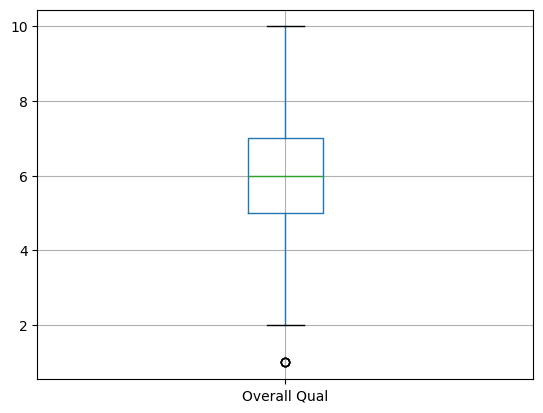

In [8]:
df.boxplot(column="Overall Qual")
# i used ai
cap_value=df['Overall Qual'].quantile(0.99)
print(f"99th percentile cap value: {cap_value}")

In [9]:
def clean_data():
  df=pd.read_csv("AmesHousing.csv")
  # ---------------------------------
  df.info()
  df['Mas Vnr Area'] = pd.to_numeric(df['Mas Vnr Area'], errors='coerce').fillna(0).astype('int64')
  df['BsmtFin SF 1'] = pd.to_numeric(df['BsmtFin SF 1'], errors='coerce').fillna(0).astype('int64')
  # ---------------------------------
  df.isnull().sum()

  for a in df.columns:
    try:
      if df[a].isnull().sum()>=500 :
        drop_c=df[a]
        df.drop(columns=a,inplace=True)
    except:
      df.drop(columns=a)

  for i in df.columns:
    try:
      if df[i].isnull().sum()>0 and df[i].isnull().sum()<500:
        df[i]=df[i].fillna(df[i].median())
    except:
      df[i]=df[i].fillna(df[i].mode()[0], inplace=True)

  missing_d=df.isnull().sum()
  print(missing_d[missing_d>0])

  # ---------------------------------
df.boxplot(column="Overall Qual")
cap_value=df['Overall Qual'].quantile(0.99)
print(f"99th percentile cap value: {cap_value}")


99th percentile cap value: 10.0


In [11]:
# i used ai
assert df["Overall Qual"].notnull().all()
# --------------------------------
assert (df["Overall Cond"]>0).all()
# --------------------------------
colunm_expected=len(df.columns)
assert len(df.columns)==colunm_expected